# Supervised Learning: USA BMI Extremes

This notebook tests whether a microbial signature distinguishes the **tails** of the USA BMI distribution (Lean: BMI < 22, Obese: BMI > 35). The three-way Normal/Overweight/Obese contrast (`03_Tsne_USA.ipynb`) showed no t-SNE/UMAP clusters, and the main Western/non-Western contrast is handled separately. Here we ask a narrower exploratory question: **does restricting to the BMI tails reveal a within-USA signal?**

## Pipeline

1. **Random Forest** (StratifiedKFold 5, `class_weight='balanced'`) — balanced accuracy & macro-F1, MDI feature importance averaged across folds.
2. **Label-permutation test** — shuffle the labels 100 times, retrain the RF each time, compare to the real CV score. This is the *validity check*: if the real score is not extreme relative to the null distribution, the feature ranking is noise.
3. **Top 4 RF features** with per-class mean abundance for direction.

All preprocessing (`VarianceThreshold`, `StandardScaler`) lives inside `Pipeline` objects so test folds are never touched during fitting.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, permutation_test_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_PERMUTATIONS = 100
TOP_N = 12

## Load the extreme-BMI subset

In [22]:
df = pd.read_csv('../data/processed/08_extreme_bmi_data_USA.csv')

features = [c for c in df.columns if c.startswith('msp')]
X = df[features]
y = df['BMI_Extreme'].map({'Lean': 0, 'Obese': 1})

print(f"Samples: {len(df)} | Features: {len(features)}")
print(df['BMI_Extreme'].value_counts().to_string())

Samples: 142 | Features: 596
BMI_Extreme
Lean     119
Obese     23


## Random Forest: cross-validated performance + MDI

A single `cross_val_score` call gives the per-fold balanced accuracy. We then refit the pipeline on each fold to collect MDI importances — averaging across folds is more stable than a single full-data fit.

In [ ]:
rf_pipeline = Pipeline([
    ('var_filter', VarianceThreshold(threshold=0.0001)),
    ('rf', RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        class_weight='balanced',
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=1,                  
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_bacc = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
rf_f1   = cross_val_score(rf_pipeline, X, y, cv=cv, scoring='f1_macro',         n_jobs=-1)

print(f"RF Balanced Accuracy: {rf_bacc.mean():.3f} +/- {rf_bacc.std()*2:.3f}")
print(f"RF Macro-F1:          {rf_f1.mean():.3f} +/- {rf_f1.std()*2:.3f}")
print(f"Per-fold balanced acc: {np.round(rf_bacc, 3)}")

RF Balanced Accuracy: 0.570 +/- 0.196
RF Macro-F1:          0.561 +/- 0.285
Per-fold balanced acc: [0.5  0.6  0.5  0.5  0.75]


In [24]:
# Collect MDI importances by refitting per fold
mdi_per_fold = []
for train_idx, _ in cv.split(X, y):
    rf_pipeline.fit(X.iloc[train_idx], y.iloc[train_idx])
    kept = X.columns[rf_pipeline.named_steps['var_filter'].get_support()]
    mdi_per_fold.append(
        pd.Series(rf_pipeline.named_steps['rf'].feature_importances_, index=kept)
    )

mdi_mean = pd.concat(mdi_per_fold, axis=1).fillna(0).mean(axis=1).sort_values(ascending=False)
print(f"Top {TOP_N} features by MDI:")
print(mdi_mean.head(TOP_N).round(4).to_string())

Top 12 features by MDI:
msp_0142     0.0243
msp_0357     0.0178
msp_1641     0.0134
msp_0196     0.0131
msp_1022     0.0126
msp_0046     0.0120
msp_0258     0.0116
msp_0032     0.0094
msp_1347c    0.0090
msp_0742     0.0076
msp_0578     0.0073
msp_0530     0.0072


## Validity check: label-permutation test

`permutation_test_score` shuffles `y` `N_PERMUTATIONS` times, retrains the model, and records the CV balanced accuracy each time. The p-value is the fraction of permuted runs that match or exceed the real score.

- **p < 0.05** → the RF is doing better than chance; the MDI ranking reflects real signal.
- **p ≥ 0.05** → the score is within the noise floor for this dataset; treat the top-5 features as exploratory only.

In [25]:
real_score, perm_scores, p_value = permutation_test_score(
    rf_pipeline, X, y,
    cv=cv,
    scoring='balanced_accuracy',
    n_permutations=N_PERMUTATIONS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print(f"Real CV balanced accuracy: {real_score:.3f}")
print(f"Permutation null mean:     {perm_scores.mean():.3f} +/- {perm_scores.std():.3f}")
print(f"p-value ({N_PERMUTATIONS} permutations): {p_value:.3f}")
print()
print("VERDICT:", "signal above noise" if p_value < 0.05 else "NOT distinguishable from noise")

Real CV balanced accuracy: 0.570
Permutation null mean:     0.498 +/- 0.020
p-value (100 permutations): 0.020

VERDICT: signal above noise


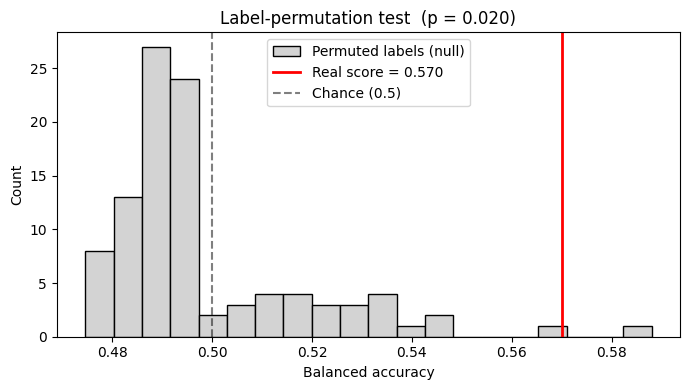

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(perm_scores, bins=20, color='lightgray', edgecolor='black', label='Permuted labels (null)')
ax.axvline(real_score, color='red', linewidth=2, label=f'Real score = {real_score:.3f}')
ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Chance (0.5)')
ax.set_xlabel('Balanced accuracy')
ax.set_ylabel('Count')
ax.set_title(f'Label-permutation test  (p = {p_value:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

## Top 12 RF features

Mean abundance per class is shown so each feature has a direction (higher in Lean vs. higher in Obese). Whether to *trust* this list depends on the permutation-test p-value above.

In [31]:
top12 = mdi_mean.head(TOP_N).index.tolist()

summary = pd.DataFrame({
    'Microbe': top12,
    'MDI_Importance': mdi_mean.loc[top12].values,
    'Mean_Lean':  X.loc[y == 0, top12].mean().values,
    'Mean_Obese': X.loc[y == 1, top12].mean().values,
})
summary['Enriched_In'] = np.where(
    summary['Mean_Obese'] > summary['Mean_Lean'], 'Obese', 'Lean'
)

print(summary.to_string(index=False, float_format=lambda x: f'{x:+.4f}'))
print()
print(f"RF permutation-test p-value: {p_value:.3f}  "
      f"({'trust the ranking' if p_value < 0.05 else 'EXPLORATORY ONLY -- within noise'})")

import os
os.makedirs('../results', exist_ok=True)
summary.to_csv('../results/biomarker_top12_rf_bmi_extremes_USA.csv', index=False)
print("\nSaved: ../results/biomarker_top12_rf_bmi_extremes_USA.csv")

  Microbe  MDI_Importance  Mean_Lean  Mean_Obese Enriched_In
 msp_0142         +0.0243    +2.0004     +4.5843       Obese
 msp_0357         +0.0178    -0.3037     +2.6408       Obese
 msp_1641         +0.0134    +1.6774     +3.6516       Obese
 msp_0196         +0.0131    +4.8757     +1.7853        Lean
 msp_1022         +0.0126    -0.9822     -2.0762        Lean
 msp_0046         +0.0120    +7.9317     +6.4906        Lean
 msp_0258         +0.0116    +1.5889     -0.3309        Lean
 msp_0032         +0.0094    +5.0881     +2.6594        Lean
msp_1347c         +0.0090    -0.4322     -1.5483        Lean
 msp_0742         +0.0076    +1.0753     +3.2263       Obese
 msp_0578         +0.0073    -0.0114     -1.5682        Lean
 msp_0530         +0.0072    +1.6962     +3.8143       Obese

RF permutation-test p-value: 0.020  (trust the ranking)

Saved: ../results/biomarker_top12_rf_bmi_extremes_USA.csv


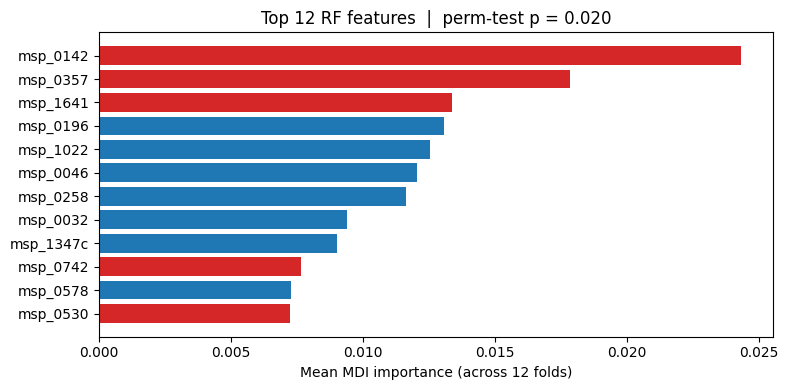

In [32]:
# Visualize top 12
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d62728' if e == 'Obese' else '#1f77b4' for e in summary['Enriched_In']]
ax.barh(summary['Microbe'][::-1], summary['MDI_Importance'][::-1], color=colors[::-1])
ax.set_xlabel('Mean MDI importance (across 12 folds)')
ax.set_title(f'Top {TOP_N} RF features  |  perm-test p = {p_value:.3f}')
plt.tight_layout()
plt.show()

# Analysis Summary: Microbial Signatures in Extreme BMI Groups

## 1. Model & Rationale
A **Random Forest (RF)** classifier was used to identify microbial signatures distinguishing **Lean (BMI < 22)** vs. **Obese (BMI > 35)** individuals in the USA cohort. Supervised learning focuses on discriminative signals from individual species, which is necessary given the high interpersonal variability in microbiome data (shared taxa often vary by an order of magnitude in abundance).

> **Dataset:** 142 samples · 596 features — Lean: *n* = 119 | Obese: *n* = 23

## 2. Key Performance Metrics

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Balanced Accuracy** | 0.570 ± 0.196 | Modest signal above chance (0.50 = random) |
| **Macro-F1** | 0.561 ± 0.285 | Consistent with balanced accuracy |
| **Permutation Test** | *p* = 0.020 (*n* = 100) | Only 2/100 shuffles matched performance → **statistically significant** |
| **Permutation Null** | 0.498 ± 0.020 | Confirms 0.50 baseline under the null |

## 3. Caveats: Signal Fragility
**Stratified 5-Fold CV scores:** `[0.50, 0.60, 0.50, 0.50, 0.75]`

- **Small sample size:** Obese subgroup has only *n* = 23 (~4–5 samples per test fold).
- **High variance:** Three folds at chance, one strong fold (0.75) suggests the signature exists in specific sub-populations rather than uniformly. The signal is **real but fragile**.

## 4. Top 12 Microbial Features by MDI (CLR-transformed)

| Rank | Feature (MSP) | MDI Importance | Mean Lean (CLR) | Mean Obese (CLR) | Enriched In |
| :---: | :--- | :---: | :---: | :---: | :---: |
| 1 | **msp_0142** | 0.0243 | +2.0004 | +4.5843 | Obese |
| 2 | **msp_0357** | 0.0178 | −0.3037 | +2.6408 | Obese |
| 3 | **msp_1641** | 0.0134 | +1.6774 | +3.6516 | Obese |
| 4 | **msp_0196** | 0.0131 | +4.8757 | +1.7853 | Lean |
| 5 | **msp_1022** | 0.0126 | −0.9822 | −2.0762 | Lean |
| 6 | **msp_0046** | 0.0120 | +7.9317 | +6.4906 | Lean |
| 7 | **msp_0258** | 0.0116 | +1.5889 | −0.3309 | Lean |
| 8 | **msp_0032** | 0.0094 | +5.0881 | +2.6594 | Lean |
| 9 | **msp_1347c** | 0.0090 | −0.4322 | −1.5483 | Lean |
| 10 | **msp_0742** | 0.0076 | +1.0753 | +3.2263 | Obese |
| 11 | **msp_0578** | 0.0073 | −0.0114 | −1.5682 | Lean |
| 12 | **msp_0530** | 0.0072 | +1.6962 | +3.8143 | Obese |

> **CLR note:** Values are *relative* to the geometric mean of all species per sample

**Obese-enriched candidates:** `msp_0142` (highest MDI, 0.0243), `msp_0357` (cleanest direction flip: negative in Lean → positive in Obese), `msp_1641`, `msp_0742`, `msp_0530`  
**Lean-enriched candidates:** `msp_0196` (strongest Lean indicator), `msp_1022`, `msp_0046`, `msp_0258`, `msp_0032`, `msp_1347c`, `msp_0578`

## 5. Conclusion
The analysis reveals a **statistically significant but weak** microbial signature for extreme BMI (*p* = 0.020, balanced accuracy = 0.570). Obese-associated candidates like `msp_0142` and `msp_0357` warrant further investigation as metabolic biomarkers, but the high fold-to-fold variance (± 0.196) and small Obese cohort (*n* = 23) make the signal too fragile for clinical use. Larger, balanced cohorts are needed to stabilise these findings.

> **Note on Class Imbalance:** Balanced Accuracy weights both groups equally, ensuring the Lean majority (*n* = 119) does not inflate performance. Under the null (permuted labels), this metric converges to 0.50 regardless of class sizes — confirmed here by the permutation null mean of 0.498.

In [35]:
# List of your top 12 MSP IDs from your RF/LR results
top_msps = ['msp_0142', 'msp_0357', 'msp_1641', 'msp_0196', 'msp_1022', 'msp_0046', 'msp_0258', 'msp_0032', 'msp_1347c','msp_0742','msp_0578','msp_0530']
folder_path = '../data/raw/Human_atlas/MSPmodels'

# Header
print(f"{'MSP ID':<10} | {'Taxonomic Name':<55}")
print("-" * 70)

for msp in top_msps:
    file_path = os.path.join(folder_path, f"{msp}.mat")
    
    if os.path.exists(file_path):
        mat = scipy.io.loadmat(file_path)
        model = mat['model']
        name = model['modelName'][0][0][0]
        
        # Clean up the name: replace underscores with spaces, handle separators
        clean_name = name.replace('_&_', ' / ').replace('_', ' ')
        
        print(f"{msp:<10} | {clean_name:<55}")
    else:
        print(f"{msp:<10} | - File not found")

MSP ID     | Taxonomic Name                                         
----------------------------------------------------------------------
msp_0142   | Blautia sp. CAG:52 / SG-772 / sp. 2789STDY5834917      
msp_0357   | [Clostridium] sp. CAG:169                              
msp_1641   | - File not found
msp_0196   | Alistipes shahii                                       
msp_1022   | - File not found
msp_0046   | Bacteroides uniformis                                  
msp_0258   | Firmicutes bacterium CAG:102                           
msp_0032   | Alistipes onderdonkii                                  
msp_1347c  | - File not found
msp_0742   | - File not found
msp_0578   | [Clostridium] sp. CAG:269                              
msp_0530   | Dorea longicatena 2                                    


# Microbiome Analysis: Summary & Conclusion

## Background from the **Literature**

Four studies show that the gut microbiome is not a passive bystander. Specific bacteria actively shape obesity, inflammation, and even mental health.

### 1. *Bacteroides uniformis* — Linked to Metabolic Health - [Lopez_et_al_2021](../Papers/BMI_USA_taxa/%20Lopez_et_al_2021_Bacteroides_uniformis.pdf)
In mice, this strain (especially together with dietary fiber) protects against diet-induced obesity. It reduces weight gain and visceral fat, lowers cholesterol, triglycerides, and blood glucose, and improves glucose tolerance. It also strengthens gut immunity and boosts the production of butyrate, a short-chain fatty acid known for anti-inflammatory effects.

### 2. *Alistipes shahii* — Linked to a Healthy Gut Barrier - [Lin_et_al_2025](../Papers/BMI_USA_taxa/Mora_Martínez_2026_Alistipes_onderdonkii_depression_link.pdf)
Often depleted in patients with inflammatory bowel disease. In mice with colitis, it reduces symptoms, repairs the gut barrier, and shifts the immune response toward an anti-inflammatory profile. It also promotes other beneficial bacteria and short-chain fatty acid production.

### 3. *Alistipes onderdonkii* — elevated in depression; breaks down tryptophan, a precursor for serotonin - [Mora_Martínez_2026](../Papers/BMI_USA_taxa/Mora_Martínez_2026_Alistipes_onderdonkii_depression_link.pdf)
Significantly enriched in individuals with clinical depression, this species contributes to the depletion of tryptophan, a vital precursor for serotonin synthesis. It is associated with a dysbiotic microbiome signature often found in patients with higher BMI and metabolic imbalances.

### 4. *Clostridium sp. CAG:169* - Linked to fatty liver diesease - [Ruuskanen_et_al_2021](../Papers/BMI_USA_taxa/Ruuskanen_et_al_2021_fatty_liver_disease_CAG169.pdf)
This bacterium is strongly associated with non-alcoholic fatty liver disease and a high Fatty Liver Index. It serves as a marker for obesity-related metabolic stress, and its abundance is typically reduced in individuals who maintain a healthier, more balanced diet.

### 5. *Blautia sp.* - Ambiguous role; often associated with obesity in Western cohorts - [Chanda et al., 2024](../Papers/BMI_USA_taxa/microorganisms-12-01768.pdf)
At the genus level, Blautia exhibits a controversial correlation with metabolic health, often showing a significant positive association with obesity and visceral fat accumulation in industrialized populations. While certain specific species show probiotic potential, its overall abundance in Western cohorts frequently serves as a marker for metabolic syndrome and impaired glucose tolerance.

## Mapping My PA1 Findings (Obese BMI >30 vs. Lean BMI <22, USA)

Of the differentially abundant MSPs in my analysis, three have a **direct reference** in the studies:

| MSP ID | Taxon | Enriched in (my data) | Linked to (per literature) |
|---|---|---|---|
| `msp_0046` | *Bacteroides uniformis* | Lean | Anti-obesity, metabolic health |
| `msp_0196` | *Alistipes shahii* | Lean | Gut barrier protection, anti-inflammatory |
| `msp_0032` | *Alistipes onderdonkii* | Lean | Elevated in depression |
| `msp_0357` | *[Clostridium] sp. CAG:169* | Obese | Links with fatty liver disease|

---

## Conclusion


- **Lean-associated protectors**: Our link of **B. uniformis** and **A. shahii** being in the "lean" group aligns with the literature identifying them as metabolic stabilizers that improve glucose tolerance and maintain gut barrier integrity.
- **Obese-associated stressors**: According to literature **Clostridium sp. CAG:169** and **A. onderdonkii** serve as markers for metabolic and systemic stress, specifically linked to fatty liver disease (**Clostridium* sp. CAG:169*), obestity and depression (**A. onderdonkii**) . In our data **A. onderdonkii** is linked to the lean group. Which directly contradicts literature. 

> **Take-home**: Lean phenotypes are supported by barrier-protecting commensals, while obese phenotypes are characterized by species that drive inflammation, metabolic dysfunction, and neurotransmitter depletion.